In [0]:
from pyspark.sql import functions as F

db_host = dbutils.secrets.get(scope="mortalidad-dw", key="host")
db_port = dbutils.secrets.get(scope="mortalidad-dw", key="port")
db_name = dbutils.secrets.get(scope="mortalidad-dw", key="database")
db_user = dbutils.secrets.get(scope="mortalidad-dw", key="user")
db_password = dbutils.secrets.get(scope="mortalidad-dw", key="password")

jdbc_url = f"jdbc:postgresql://{db_host}:{db_port}/{db_name}"

connection_properties = {
    "user": db_user,
    "password": db_password,
    "driver": "org.postgresql.Driver"
}

def leer_dw(sql):
    query = f"""
    (
        {sql}
    ) AS consulta_dw
    """
    
    return spark.read.jdbc(
        url=jdbc_url,
        table=query,
        properties=connection_properties
    )

    

In [0]:
sql_defunciones_gt = """
SELECT
    g.nombre_departamento AS departamento,
    t.anio,
    t.mes,
    SUM(f.total_casos) AS muertes_observadas,
    COUNT(DISTINCT g.nombre_municipio) AS municipios_con_datos
FROM dw.fact_defunciones_gt f
INNER JOIN dw.dim_tiempo t
    ON f.id_tiempo = t.id_tiempo
INNER JOIN dw.dim_geografia_gt g
    ON f.id_geografia = g.id_geografia
WHERE t.anio BETWEEN 2018 AND 2024
  AND t.mes BETWEEN 1 AND 12
  AND f.total_casos IS NOT NULL
  AND g.nombre_departamento IS NOT NULL
GROUP BY
    g.nombre_departamento,
    t.anio,
    t.mes
ORDER BY
    g.nombre_departamento,
    t.anio,
    t.mes
"""

df_defunciones_gt_spark = leer_dw(sql_defunciones_gt)

display(df_defunciones_gt_spark)

departamento,anio,mes,muertes_observadas,municipios_con_datos
Alta Verapaz,2018,1,483.000000000000000000,17
Alta Verapaz,2018,2,376.000000000000000000,17
Alta Verapaz,2018,3,417.000000000000000000,17
Alta Verapaz,2018,4,413.000000000000000000,17
Alta Verapaz,2018,5,442.000000000000000000,17
Alta Verapaz,2018,6,393.000000000000000000,17
Alta Verapaz,2018,7,462.000000000000000000,17
Alta Verapaz,2018,8,380.000000000000000000,17
Alta Verapaz,2018,9,417.000000000000000000,17
Alta Verapaz,2018,10,447.000000000000000000,17


In [0]:
import pandas as pd
import numpy as np

df = df_defunciones_gt_spark.toPandas()

df["anio"] = df["anio"].astype(int)
df["mes"] = df["mes"].astype(int)
df["muertes_observadas"] = pd.to_numeric(df["muertes_observadas"], errors="coerce")
df["municipios_con_datos"] = pd.to_numeric(df["municipios_con_datos"], errors="coerce")

print("Total de registros:", len(df))
print("Año mínimo:", df["anio"].min())
print("Año máximo:", df["anio"].max())
print("Departamentos:", df["departamento"].nunique())

display(
    df
    .groupby("anio", as_index=False)
    .agg(
        total_muertes=("muertes_observadas", "sum"),
        departamentos=("departamento", "nunique"),
        meses=("mes", "nunique")
    )
)

Total de registros: 1848
Año mínimo: 2018
Año máximo: 2024
Departamentos: 22


anio,total_muertes,departamentos,meses
2018,83071.0,22,12
2019,85600.0,22,12
2020,96001.0,22,12
2021,118465.0,22,12
2022,95386.0,22,12
2023,95948.0,22,12
2024,99593.0,22,12


In [0]:
# construir línea base pre-COVID 2018–2019
# Línea base histórica pre-COVID
# Se calcula por departamento y mes usando 2018-2019

df_pre = df[(df["anio"] >= 2018) & (df["anio"] <= 2019)].copy()

baseline = (
    df_pre
    .groupby(["departamento", "mes"], as_index=False)
    .agg(
        promedio_pre_covid=("muertes_observadas", "mean"),
        desviacion_pre_covid=("muertes_observadas", "std")
    )
)

baseline["desviacion_pre_covid"] = baseline["desviacion_pre_covid"].fillna(0)

display(baseline)

departamento,mes,promedio_pre_covid,desviacion_pre_covid
Alta Verapaz,1,478.0,7.0710678118654755
Alta Verapaz,2,384.0,11.313708498984761
Alta Verapaz,3,424.0,9.899494936611665
Alta Verapaz,4,419.0,8.48528137423857
Alta Verapaz,5,455.0,18.384776310850235
Alta Verapaz,6,435.5,60.10407640085654
Alta Verapaz,7,469.5,10.606601717798213
Alta Verapaz,8,437.0,80.61017305526642
Alta Verapaz,9,441.0,33.94112549695428
Alta Verapaz,10,451.0,5.656854249492381


In [0]:
# crear variable objetivo exceso_mortalidad
# Crear dataset final para ML
# 

df_modelo = df.merge(
    baseline,
    on=["departamento", "mes"],
    how="left"
)

df_modelo = df_modelo.dropna(subset=["promedio_pre_covid"])

df_modelo["exceso_pct"] = (
    (df_modelo["muertes_observadas"] - df_modelo["promedio_pre_covid"])
    / df_modelo["promedio_pre_covid"]
)

df_modelo["exceso_mortalidad"] = np.where(
    df_modelo["exceso_pct"] >= 0.15,
    1,
    0
)

df_modelo["exceso_pct_display"] = df_modelo["exceso_pct"] * 100

display(df_modelo[[
    "departamento",
    "anio",
    "mes",
    "muertes_observadas",
    "promedio_pre_covid",
    "desviacion_pre_covid",
    "exceso_pct",
    "exceso_mortalidad"
]].head(30))

departamento,anio,mes,muertes_observadas,promedio_pre_covid,desviacion_pre_covid,exceso_pct,exceso_mortalidad
Alta Verapaz,2018,1,483.0,478.0,7.0710678118654755,0.010460251046025104,0
Alta Verapaz,2018,2,376.0,384.0,11.313708498984761,-0.020833333333333332,0
Alta Verapaz,2018,3,417.0,424.0,9.899494936611665,-0.01650943396226415,0
Alta Verapaz,2018,4,413.0,419.0,8.48528137423857,-0.014319809069212411,0
Alta Verapaz,2018,5,442.0,455.0,18.384776310850235,-0.02857142857142857,0
Alta Verapaz,2018,6,393.0,435.5,60.10407640085654,-0.09758897818599312,0
Alta Verapaz,2018,7,462.0,469.5,10.606601717798213,-0.01597444089456869,0
Alta Verapaz,2018,8,380.0,437.0,80.61017305526642,-0.13043478260869565,0
Alta Verapaz,2018,9,417.0,441.0,33.94112549695428,-0.05442176870748299,0
Alta Verapaz,2018,10,447.0,451.0,5.656854249492381,-0.008869179600886918,0


In [0]:
# distribución de la variable objetivo
resumen_clases = (
    df_modelo
    .groupby("exceso_mortalidad", as_index=False)
    .agg(
        registros=("exceso_mortalidad", "count")
    )
)

resumen_clases["porcentaje"] = (
    resumen_clases["registros"] / resumen_clases["registros"].sum()
) * 100

display(resumen_clases)

exceso_mortalidad,registros,porcentaje
0,1131,61.201298701298704
1,717,38.798701298701296


fecha,departamento,anio,mes,muertes_observadas,promedio_pre_covid,umbral_15,exceso_pct,exceso_mortalidad
2018-01-01T00:00:00.000Z,Guatemala,2018,1,2080.0,2064.5,2374.1749999999997,0.007507871155243401,0
2018-02-01T00:00:00.000Z,Guatemala,2018,2,1725.0,1776.0,2042.3999999999999,-0.028716216216216218,0
2018-03-01T00:00:00.000Z,Guatemala,2018,3,1892.0,2002.0,2302.2999999999997,-0.054945054945054944,0
2018-04-01T00:00:00.000Z,Guatemala,2018,4,1982.0,1998.5,2298.2749999999996,-0.00825619214410808,0
2018-05-01T00:00:00.000Z,Guatemala,2018,5,1964.0,2047.0,2354.0499999999997,-0.04054714215925745,0
2018-06-01T00:00:00.000Z,Guatemala,2018,6,2030.0,2015.5,2317.825,0.007194244604316547,0
2018-07-01T00:00:00.000Z,Guatemala,2018,7,2039.0,2108.5,2424.7749999999996,-0.03296182119990514,0
2018-08-01T00:00:00.000Z,Guatemala,2018,8,2001.0,2063.5,2373.0249999999996,-0.03028834504482675,0
2018-09-01T00:00:00.000Z,Guatemala,2018,9,1966.0,1971.0,2266.6499999999996,-0.0025367833587011668,0
2018-10-01T00:00:00.000Z,Guatemala,2018,10,2086.0,2092.5,2406.375,-0.003106332138590203,0


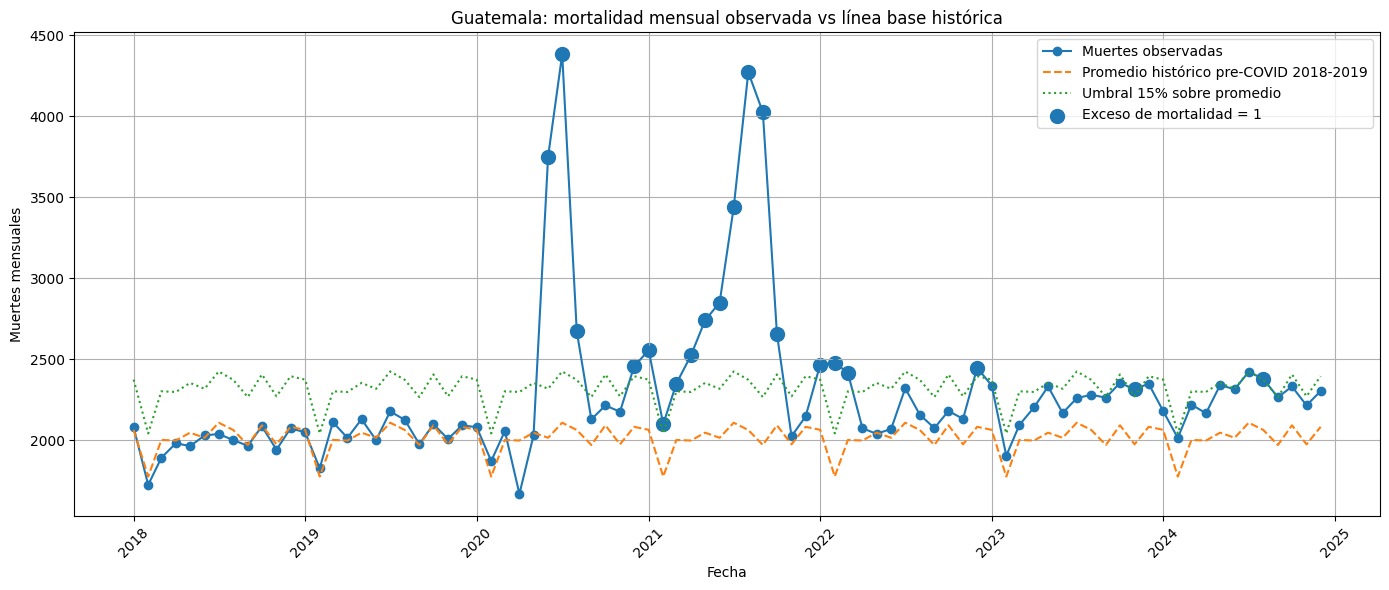

In [0]:
# gráfica de un departamento específico
import matplotlib.pyplot as plt

departamento_objetivo = "Guatemala"

df_depto = df_modelo[
    df_modelo["departamento"].str.upper() == departamento_objetivo.upper()
].copy()

if df_depto.empty:
    raise ValueError(f"No se encontraron datos para el departamento: {departamento_objetivo}")

df_depto["fecha"] = pd.to_datetime(
    df_depto["anio"].astype(str) + "-" +
    df_depto["mes"].astype(str) + "-01"
)

df_depto = df_depto.sort_values("fecha")

df_depto["umbral_15"] = df_depto["promedio_pre_covid"] * 1.15

display(df_depto[[
    "fecha",
    "departamento",
    "anio",
    "mes",
    "muertes_observadas",
    "promedio_pre_covid",
    "umbral_15",
    "exceso_pct",
    "exceso_mortalidad"
]])

plt.figure(figsize=(14, 6))

plt.plot(
    df_depto["fecha"],
    df_depto["muertes_observadas"],
    marker="o",
    label="Muertes observadas"
)

plt.plot(
    df_depto["fecha"],
    df_depto["promedio_pre_covid"],
    linestyle="--",
    label="Promedio histórico pre-COVID 2018-2019"
)

plt.plot(
    df_depto["fecha"],
    df_depto["umbral_15"],
    linestyle=":",
    label="Umbral 15% sobre promedio"
)

df_exceso = df_depto[df_depto["exceso_mortalidad"] == 1]

plt.scatter(
    df_exceso["fecha"],
    df_exceso["muertes_observadas"],
    s=100,
    label="Exceso de mortalidad = 1"
)

plt.title(f"{departamento_objetivo}: mortalidad mensual observada vs línea base histórica")
plt.xlabel("Fecha")
plt.ylabel("Muertes mensuales")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [0]:
# preparación de datos para Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

features = [
    "departamento",
    "anio",
    "mes",
    "promedio_pre_covid",
    "desviacion_pre_covid"
]

target = "exceso_mortalidad"

df_ml = df_modelo[features + [target]].copy()
df_ml = df_ml.dropna()

X = df_ml[features]
y = df_ml[target]

print("Registros para ML:", len(df_ml))
print("Distribución de clases:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

Registros para ML: 1848
Distribución de clases:
exceso_mortalidad
0    1131
1     717
Name: count, dtype: int64


In [0]:
# entrenar Regresión Logística
categorical_features = ["departamento"]
numeric_features = [
    "anio",
    "mes",
    "promedio_pre_covid",
    "desviacion_pre_covid"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

model.fit(X_train, y_train)

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['departamento']),
                                                 ('num', StandardScaler(),
                                                  ['anio', 'mes',
                                                   'promedio_pre_covid',
                                                   'desviacion_pre_covid'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [0]:
# evaluación inicial con umbral 0.50
y_pred_default = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred_default)
precision = precision_score(y_test, y_pred_default, zero_division=0)
recall = recall_score(y_test, y_pred_default, zero_division=0)
f1 = f1_score(y_test, y_pred_default, zero_division=0)
cm = confusion_matrix(y_test, y_pred_default)

print("Evaluación inicial con umbral 0.50")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("Matriz de confusión:")
print(cm)
print(classification_report(y_test, y_pred_default, zero_division=0))

Evaluación inicial con umbral 0.50
Accuracy: 0.6883116883116883
Precision: 0.579185520361991
Recall: 0.7150837988826816
F1: 0.64
Matriz de confusión:
[[190  93]
 [ 51 128]]
              precision    recall  f1-score   support

           0       0.79      0.67      0.73       283
           1       0.58      0.72      0.64       179

    accuracy                           0.69       462
   macro avg       0.68      0.69      0.68       462
weighted avg       0.71      0.69      0.69       462



In [0]:
# probar varios umbrales
resultados_umbral = []

y_proba = model.predict_proba(X_test)[:, 1]

umbrales = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75]

for umbral in umbrales:
    y_pred_umbral = (y_proba >= umbral).astype(int)

    accuracy = accuracy_score(y_test, y_pred_umbral)
    precision = precision_score(y_test, y_pred_umbral, zero_division=0)
    recall = recall_score(y_test, y_pred_umbral, zero_division=0)
    f1 = f1_score(y_test, y_pred_umbral, zero_division=0)
    cm = confusion_matrix(y_test, y_pred_umbral)

    tn, fp, fn, tp = cm.ravel()

    resultados_umbral.append({
        "umbral": umbral,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "verdaderos_negativos": tn,
        "falsos_positivos": fp,
        "falsos_negativos": fn,
        "verdaderos_positivos": tp
    })

df_umbrales = pd.DataFrame(resultados_umbral)

display(df_umbrales)


umbral,accuracy,precision,recall,f1,verdaderos_negativos,falsos_positivos,falsos_negativos,verdaderos_positivos
0.4,0.7164502164502164,0.5916030534351145,0.8659217877094972,0.7029478458049887,176,107,24,155
0.45,0.7142857142857143,0.6,0.7877094972067039,0.6811594202898551,189,94,38,141
0.5,0.6883116883116883,0.579185520361991,0.7150837988826816,0.64,190,93,51,128
0.55,0.6796536796536796,0.5786802030456852,0.6368715083798883,0.6063829787234043,200,83,65,114
0.6,0.6688311688311688,0.5764705882352941,0.547486033519553,0.5616045845272206,211,72,81,98
0.65,0.6796536796536796,0.6040268456375839,0.5027932960893855,0.5487804878048781,224,59,89,90
0.7,0.683982683982684,0.6341463414634146,0.43575418994413406,0.5165562913907285,238,45,101,78
0.75,0.6904761904761905,0.6764705882352942,0.3854748603351955,0.49110320284697506,250,33,110,69


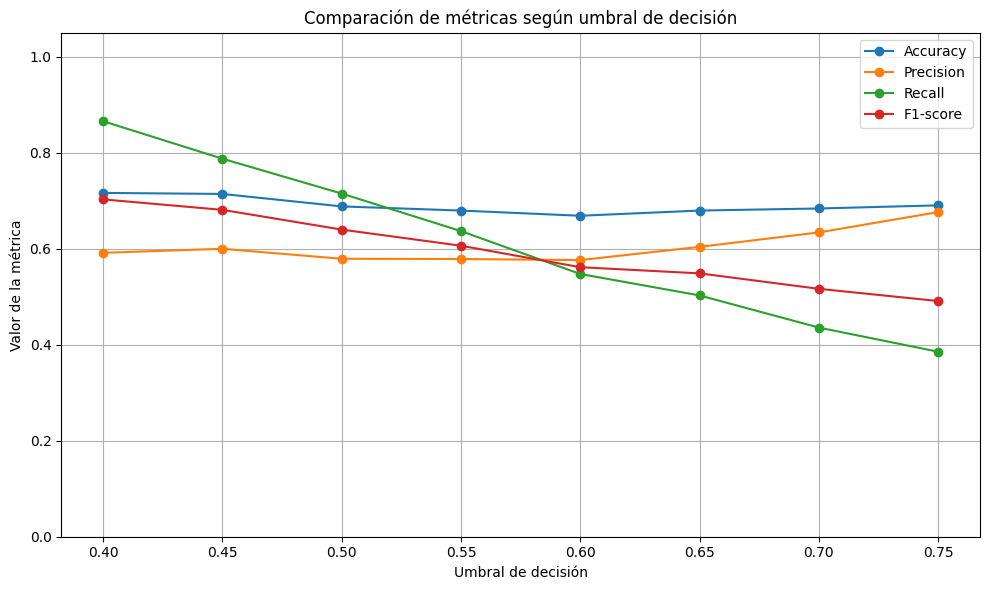

In [0]:
# gráfica de comparación de umbrales
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(df_umbrales["umbral"], df_umbrales["accuracy"], marker="o", label="Accuracy")
plt.plot(df_umbrales["umbral"], df_umbrales["precision"], marker="o", label="Precision")
plt.plot(df_umbrales["umbral"], df_umbrales["recall"], marker="o", label="Recall")
plt.plot(df_umbrales["umbral"], df_umbrales["f1"], marker="o", label="F1-score")

plt.title("Comparación de métricas según umbral de decisión")
plt.xlabel("Umbral de decisión")
plt.ylabel("Valor de la métrica")
plt.xticks(df_umbrales["umbral"])
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [0]:
# seleccionar mejor umbral
mejor_umbral = df_umbrales.loc[df_umbrales["f1"].idxmax()]

umbral_final = float(mejor_umbral["umbral"])

print("Mejor umbral según F1-score")
print("Umbral:", umbral_final)
print("Accuracy:", mejor_umbral["accuracy"])
print("Precision:", mejor_umbral["precision"])
print("Recall:", mejor_umbral["recall"])
print("F1:", mejor_umbral["f1"])
print("Falsos positivos:", mejor_umbral["falsos_positivos"])
print("Falsos negativos:", mejor_umbral["falsos_negativos"])

Mejor umbral según F1-score
Umbral: 0.4
Accuracy: 0.7164502164502164
Precision: 0.5916030534351145
Recall: 0.8659217877094972
F1: 0.7029478458049887
Falsos positivos: 107.0
Falsos negativos: 24.0


In [0]:
# evaluación final
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= umbral_final).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("Evaluación final")
print("Umbral final:", umbral_final)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("Matriz de confusión:")
print(cm)
print(classification_report(y_test, y_pred, zero_division=0))

Evaluación final
Umbral final: 0.4
Accuracy: 0.7164502164502164
Precision: 0.5916030534351145
Recall: 0.8659217877094972
F1: 0.7029478458049887
Matriz de confusión:
[[176 107]
 [ 24 155]]
              precision    recall  f1-score   support

           0       0.88      0.62      0.73       283
           1       0.59      0.87      0.70       179

    accuracy                           0.72       462
   macro avg       0.74      0.74      0.72       462
weighted avg       0.77      0.72      0.72       462



In [0]:
# ver pesos aprendidos
preprocessor_export = model.named_steps["preprocessor"]
classifier_export = model.named_steps["classifier"]

feature_names = preprocessor_export.get_feature_names_out()
coefficients = classifier_export.coef_[0]
intercept = classifier_export.intercept_[0]

df_coeficientes = pd.DataFrame({
    "feature": feature_names,
    "coeficiente_peso": coefficients
})

df_coeficientes["intercept_bias"] = intercept

display(df_coeficientes)

feature,coeficiente_peso,intercept_bias
cat__departamento_Alta Verapaz,-0.6656782461512393,-0.14785131438881766
cat__departamento_Baja Verapaz,-0.5071471851749088,-0.14785131438881766
cat__departamento_Chimaltenango,0.2783152654765672,-0.14785131438881766
cat__departamento_Chiquimula,-0.453458681598338,-0.14785131438881766
cat__departamento_El Progreso,-0.119204788457161,-0.14785131438881766
cat__departamento_Escuintla,-0.42662324511505456,-0.14785131438881766
cat__departamento_Guatemala,0.6310058085812121,-0.14785131438881766
cat__departamento_Huehuetenango,0.1419580005274422,-0.14785131438881766
cat__departamento_Izabal,0.12118783275110716,-0.14785131438881766
cat__departamento_Jalapa,-1.389761449556554,-0.14785131438881766


In [0]:
# exportar modelo a .tar.gz
import os
import json
import tarfile
import joblib
import shutil
import base64
from datetime import datetime
from IPython.display import HTML, display

# ============================================================
# Carpeta temporal local
# ============================================================

output_dir = "/tmp/modelo_exceso_mortalidad_gt_departamentos"
os.makedirs(output_dir, exist_ok=True)

model_path = f"{output_dir}/modelo_logreg_defunciones_gt.joblib"
feature_columns_path = f"{output_dir}/feature_columns.joblib"
config_path = f"{output_dir}/config_modelo.json"
metrics_path = f"{output_dir}/metricas_modelo.json"
confusion_path = f"{output_dir}/matriz_confusion.csv"
thresholds_path = f"{output_dir}/comparacion_umbrales.csv"
coefficients_path = f"{output_dir}/coeficientes_modelo.csv"
readme_path = f"{output_dir}/README_modelo.txt"
baseline_path = f"{output_dir}/baseline_pre_covid.csv"

# ============================================================
# Guardar modelo y columnas
# ============================================================

joblib.dump(model, model_path)
joblib.dump(features, feature_columns_path)
baseline.to_csv(baseline_path, index=False, encoding="utf-8")

# ============================================================
# Guardar configuración del modelo
# ============================================================

config_modelo = {
    "modelo": "Regresion Logistica",
    "problema": "Clasificacion de exceso de mortalidad en Guatemala por departamento y mes",
    "variable_objetivo": "exceso_mortalidad",
    "definicion_exceso": "1 si muertes_observadas >= 15% sobre el promedio historico pre-COVID 2018-2019 del mismo departamento y mes",
    "baseline_pre_covid": "2018-2019",
    "umbral_exceso_variable_objetivo": 0.15,
    "umbral_decision_modelo": float(umbral_final),
    "features": features,
    "target": target
}

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config_modelo, f, indent=4, ensure_ascii=False)

# ============================================================
# Guardar métricas
# ============================================================

metricas = {
    "modelo": "Regresion Logistica",
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
    "umbral_decision": float(umbral_final),
    "matriz_confusion": cm.tolist(),
    "features": features,
    "fecha_exportacion": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "herramienta": "Databricks",
    "libreria_modelo": "scikit-learn"
}

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metricas, f, indent=4, ensure_ascii=False)

# ============================================================
# Guardar matriz de confusión
# ============================================================

df_confusion = pd.DataFrame(
    cm,
    columns=["Pred_No_Exceso", "Pred_Exceso"],
    index=["Real_No_Exceso", "Real_Exceso"]
)

df_confusion.to_csv(confusion_path, encoding="utf-8")

# ============================================================
# Guardar comparación de umbrales y coeficientes
# ============================================================

df_umbrales.to_csv(thresholds_path, index=False, encoding="utf-8")
df_coeficientes.to_csv(coefficients_path, index=False, encoding="utf-8")

# ============================================================
# README del modelo
# ============================================================

readme_text = f"""
Modelo de Machine Learning - Regresion Logistica

Problema:
Clasificacion de exceso de mortalidad en Guatemala por departamento y mes.

Fuente:
dw.fact_defunciones_gt

Grano del modelo:
departamento - anio - mes

Variable objetivo:
exceso_mortalidad

Definicion:
La variable objetivo toma valor 1 cuando las muertes observadas superan en al menos 15%
el promedio historico pre-COVID 2018-2019 para el mismo departamento y mes.
En caso contrario, toma valor 0.

Modelo:
Regresion Logistica entrenada en Databricks usando scikit-learn.

Umbral de decision del modelo:
{umbral_final}

Metricas finales:
Accuracy: {accuracy}
Precision: {precision}
Recall: {recall}
F1-score: {f1}

Matriz de confusion:
{cm}

Archivos incluidos:
- modelo_logreg_defunciones_gt.joblib
- feature_columns.joblib
- config_modelo.json
- metricas_modelo.json
- matriz_confusion.csv
- comparacion_umbrales.csv
- coeficientes_modelo.csv
- README_modelo.txt

Seguridad:
No se incluyen credenciales ni secrets dentro de este archivo.
La conexion al DW se realizo mediante dbutils.secrets.get().
"""

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_text)

# ============================================================
# Crear .tar.gz
# ============================================================

tar_path = "/tmp/modelo_exceso_mortalidad_gt_departamentos_logreg.tar.gz"

with tarfile.open(tar_path, "w:gz") as tar:
    tar.add(model_path, arcname="modelo_logreg_defunciones_gt.joblib")
    tar.add(feature_columns_path, arcname="feature_columns.joblib")
    tar.add(config_path, arcname="config_modelo.json")
    tar.add(metrics_path, arcname="metricas_modelo.json")
    tar.add(confusion_path, arcname="matriz_confusion.csv")
    tar.add(thresholds_path, arcname="comparacion_umbrales.csv")
    tar.add(coefficients_path, arcname="coeficientes_modelo.csv")
    tar.add(readme_path, arcname="README_modelo.txt")
    tar.add(baseline_path, arcname="baseline_pre_covid.csv")

print("Modelo comprimido correctamente:")
print(tar_path)

# ============================================================
# Copiar a Workspace Files
# ============================================================

current_user = spark.sql("SELECT current_user()").collect()[0][0]
workspace_user_dir = "/Workspace/Users/" + current_user
workspace_model_dir = workspace_user_dir + "/modelos_ml"

os.makedirs(workspace_model_dir, exist_ok=True)

workspace_tar_path = workspace_model_dir + "/modelo_exceso_mortalidad_gt_departamentos_logreg.tar.gz"

shutil.copyfile(tar_path, workspace_tar_path)

print("Archivo copiado a Workspace Files:")
print(workspace_tar_path)

# ============================================================
# Botón de descarga directa
# ============================================================

with open(tar_path, "rb") as f:
    data = f.read()

b64 = base64.b64encode(data).decode()

html = f"""
<a download="modelo_exceso_mortalidad_gt_departamentos_logreg.tar.gz"
   href="data:application/gzip;base64,{b64}"
   style="
       display: inline-block;
       padding: 10px 15px;
       background-color: #1f6feb;
       color: white;
       text-decoration: none;
       border-radius: 6px;
       font-weight: bold;
   ">
   Descargar modelo .tar.gz
</a>
"""

display(HTML(html))

Modelo comprimido correctamente:
/tmp/modelo_exceso_mortalidad_gt_departamentos_logreg.tar.gz
Archivo copiado a Workspace Files:
/Workspace/Users/3249400331332@ingenieria.usac.edu.gt/modelos_ml/modelo_exceso_mortalidad_gt_departamentos_logreg.tar.gz


In [0]:
# verificar contenido del .tar.gz
import tarfile

with tarfile.open(tar_path, "r:gz") as tar:
    print("Archivos incluidos en el paquete:")
    for member in tar.getmembers():
        print("-", member.name)

Archivos incluidos en el paquete:
- modelo_logreg_defunciones_gt.joblib
- feature_columns.joblib
- config_modelo.json
- metricas_modelo.json
- matriz_confusion.csv
- comparacion_umbrales.csv
- coeficientes_modelo.csv
- README_modelo.txt
- baseline_pre_covid.csv


In [0]:
# ejemplo de uso del modelo entrenado
import joblib
import pandas as pd

modelo_cargado = joblib.load(model_path)
feature_columns = joblib.load(feature_columns_path)

print("Columnas esperadas:")
print(feature_columns)

nuevo_dato = pd.DataFrame([
    {
        "departamento": "Guatemala",
        "anio": 2026,
        "mes": 6,
        "promedio_pre_covid": 900,
        "desviacion_pre_covid": 80
    }
])

probabilidad = modelo_cargado.predict_proba(nuevo_dato)[:, 1]
prediccion = (probabilidad >= umbral_final).astype(int)

print("Probabilidad de exceso de mortalidad:", probabilidad[0])
print("Predicción final:", prediccion[0])

Columnas esperadas:
['departamento', 'anio', 'mes', 'promedio_pre_covid', 'desviacion_pre_covid']
Probabilidad de exceso de mortalidad: 0.9647734844185373
Predicción final: 1


In [0]:
# registrar modelo en MLflow / Databricks
import mlflow
import mlflow.pyfunc
from mlflow.models.signature import infer_signature

# ============================================================
# Experimento MLflow
# ============================================================

current_user = spark.sql("SELECT current_user()").collect()[0][0]
experiment_path = f"/Users/{current_user}/ml_exceso_mortalidad_gt_departamentos"

mlflow.set_experiment(experiment_path)

print("Experimento MLflow:")
print(experiment_path)

# ============================================================
# Resolver Model Registry
# ============================================================

use_uc = True

try:
    mlflow.set_registry_uri("databricks-uc")

    catalogs = [row.catalog for row in spark.sql("SHOW CATALOGS").collect()]
    current_catalog = spark.sql("SELECT current_catalog()").collect()[0][0]

    if "workspace" in catalogs:
        catalog_name = "workspace"
    elif current_catalog not in ["hive_metastore", "spark_catalog"]:
        catalog_name = current_catalog
    else:
        raise Exception("No hay catálogo Unity Catalog útil disponible.")

    schema_name = "default"

    spark.sql(f"CREATE SCHEMA IF NOT EXISTS `{catalog_name}`.`{schema_name}`")

    registered_model_name = f"{catalog_name}.{schema_name}.modelo_exceso_mortalidad_gt_departamentos"

except Exception as e:
    print("No se pudo usar Unity Catalog. Se usará Model Registry clásico.")
    print(e)

    use_uc = False
    mlflow.set_registry_uri("databricks")
    registered_model_name = "modelo_exceso_mortalidad_gt_departamentos"

print("Modelo registrado como:")
print(registered_model_name)

# ============================================================
# Clase PyFunc para aplicar umbral personalizado
# ============================================================

class ExcesoMortalidadGTModel(mlflow.pyfunc.PythonModel):

    def load_context(self, context):
        import joblib
        import json

        self.model = joblib.load(context.artifacts["modelo_joblib"])

        with open(context.artifacts["config_json"], "r", encoding="utf-8") as f:
            self.config = json.load(f)

        self.features = self.config["features"]
        self.umbral = self.config["umbral_decision_modelo"]

    def predict(self, context, model_input):
        import pandas as pd

        X = model_input[self.features].copy()

        probabilidad = self.model.predict_proba(X)[:, 1]
        prediccion = (probabilidad >= self.umbral).astype(int)

        return pd.DataFrame({
            "probabilidad_exceso_mortalidad": probabilidad,
            "prediccion_exceso_mortalidad": prediccion
        })

# ============================================================
# Input example y signature
# ============================================================

input_example = X_train.head(5).copy()

output_example = pd.DataFrame({
    "probabilidad_exceso_mortalidad": model.predict_proba(input_example)[:, 1],
    "prediccion_exceso_mortalidad": (
        model.predict_proba(input_example)[:, 1] >= umbral_final
    ).astype(int)
})

signature = infer_signature(input_example, output_example)

# ============================================================
# Registrar en MLflow
# ============================================================

with mlflow.start_run(run_name="regresion_logistica_exceso_mortalidad_gt_departamentos") as run:

    # Parámetros
    mlflow.log_param("modelo", "Regresion Logistica")
    mlflow.log_param("fuente", "dw.fact_defunciones_gt")
    mlflow.log_param("grano", "departamento-anio-mes")
    mlflow.log_param("baseline_pre_covid", "2018-2019")
    mlflow.log_param("umbral_variable_objetivo", 0.15)
    mlflow.log_param("umbral_decision_modelo", umbral_final)
    mlflow.log_param("features", ", ".join(features))
    mlflow.log_param("target", target)

    # Métricas
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)

    # Artefactos
    mlflow.log_artifact(metrics_path)
    mlflow.log_artifact(confusion_path)
    mlflow.log_artifact(thresholds_path)
    mlflow.log_artifact(coefficients_path)
    mlflow.log_artifact(readme_path)
    mlflow.log_artifact(config_path)
    mlflow.log_artifact(tar_path)
    mlflow.log_artifact(baseline_path)

    # Modelo PyFunc
    mlflow.pyfunc.log_model(
        artifact_path="modelo_exceso_mortalidad_gt_departamentos",
        python_model=ExcesoMortalidadGTModel(),
        artifacts={
            "modelo_joblib": model_path,
            "config_json": config_path
        },
        signature=signature,
        input_example=input_example,
        registered_model_name=registered_model_name
    )

    run_id = run.info.run_id

print("Modelo registrado correctamente en MLflow.")
print("Run ID:", run_id)
print("Modelo registrado como:")
print(registered_model_name)
print("Model URI:")
print(f"runs:/{run_id}/modelo_exceso_mortalidad_gt_departamentos")


Experimento MLflow:
/Users/3249400331332@ingenieria.usac.edu.gt/ml_exceso_mortalidad_gt_departamentos
Modelo registrado como:
workspace.default.modelo_exceso_mortalidad_gt_departamentos


/databricks/python/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://ww

Registered model 'workspace.default.modelo_exceso_mortalidad_gt_departamentos' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/13 [00:00<?, ?it/s]

🔗 Created version '3' of model 'workspace.default.modelo_exceso_mortalidad_gt_departamentos': https://dbc-1ef14a58-790f.cloud.databricks.com/explore/data/models/workspace/default/modelo_exceso_mortalidad_gt_departamentos/version/3?o=7474644210561882


Modelo registrado correctamente en MLflow.
Run ID: 8d189639288f45a38e3362d2d283f6fd
Modelo registrado como:
workspace.default.modelo_exceso_mortalidad_gt_departamentos
Model URI:
runs:/8d189639288f45a38e3362d2d283f6fd/modelo_exceso_mortalidad_gt_departamentos


In [0]:
# probar el modelo registrado en MLflow
# model_uri = f"runs:/{run_id}/modelo_exceso_mortalidad_gt_departamentos"

#modelo_mlflow = mlflow.pyfunc.load_model(model_uri)

#predicciones_prueba = modelo_mlflow.predict(input_example)

#display(predicciones_prueba)